In [5]:

import pandas as pd
import numpy as np

df = pd.read_csv("titanic.csv")

print(df.shape)

#Prepare modeling data

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"

X = df[features]
y = df[target]

(891, 15)


In [6]:
#Check class balance

class_balance = y.value_counts()
class_percentage = y.value_counts(normalize=True) * 100

print(class_balance)
print(class_percentage)

#Split BEFORE preprocessing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)



survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64
Training: (712, 7)
Testing: (179, 7)


In [8]:
#Build ColumnTransformer

#Numeric columns:

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]


In [10]:
#Categorical:

categorical_features = [
    "sex",
    "embarked"
]

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

#Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)


# Decision Tree

from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )
    )
])

tree_pipeline.fit(
    X_train,
    y_train
)

# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])

rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

,Model,accuracy,precision,recall,f1,auc
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
1,Decision Tree,0.765363,0.754717,0.579710,0.655738,0.797101
2,Random Forest,0.815642,0.800000,0.695652,0.744186,0.830040


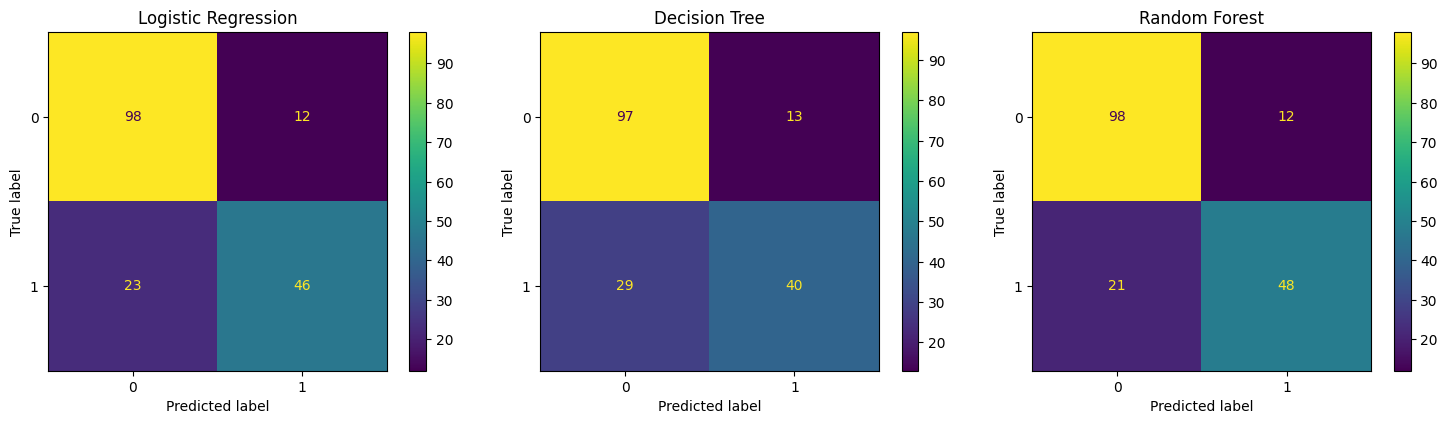

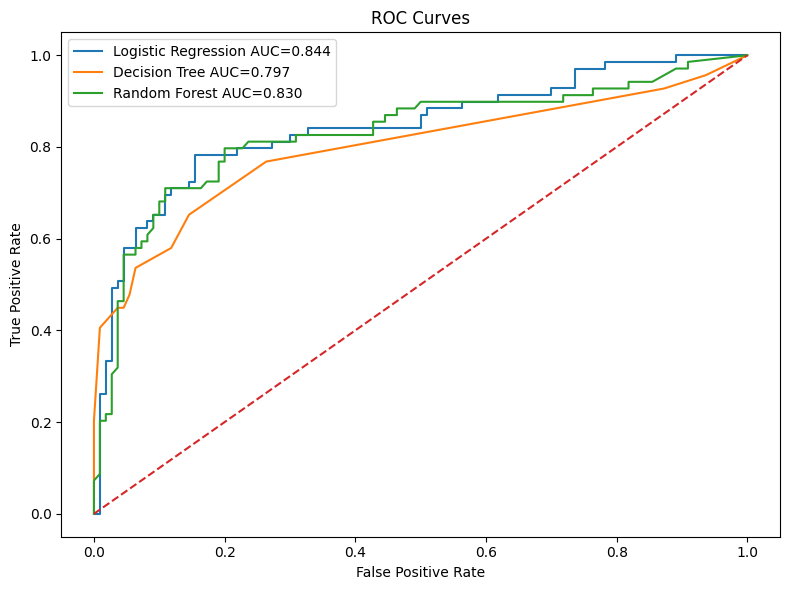

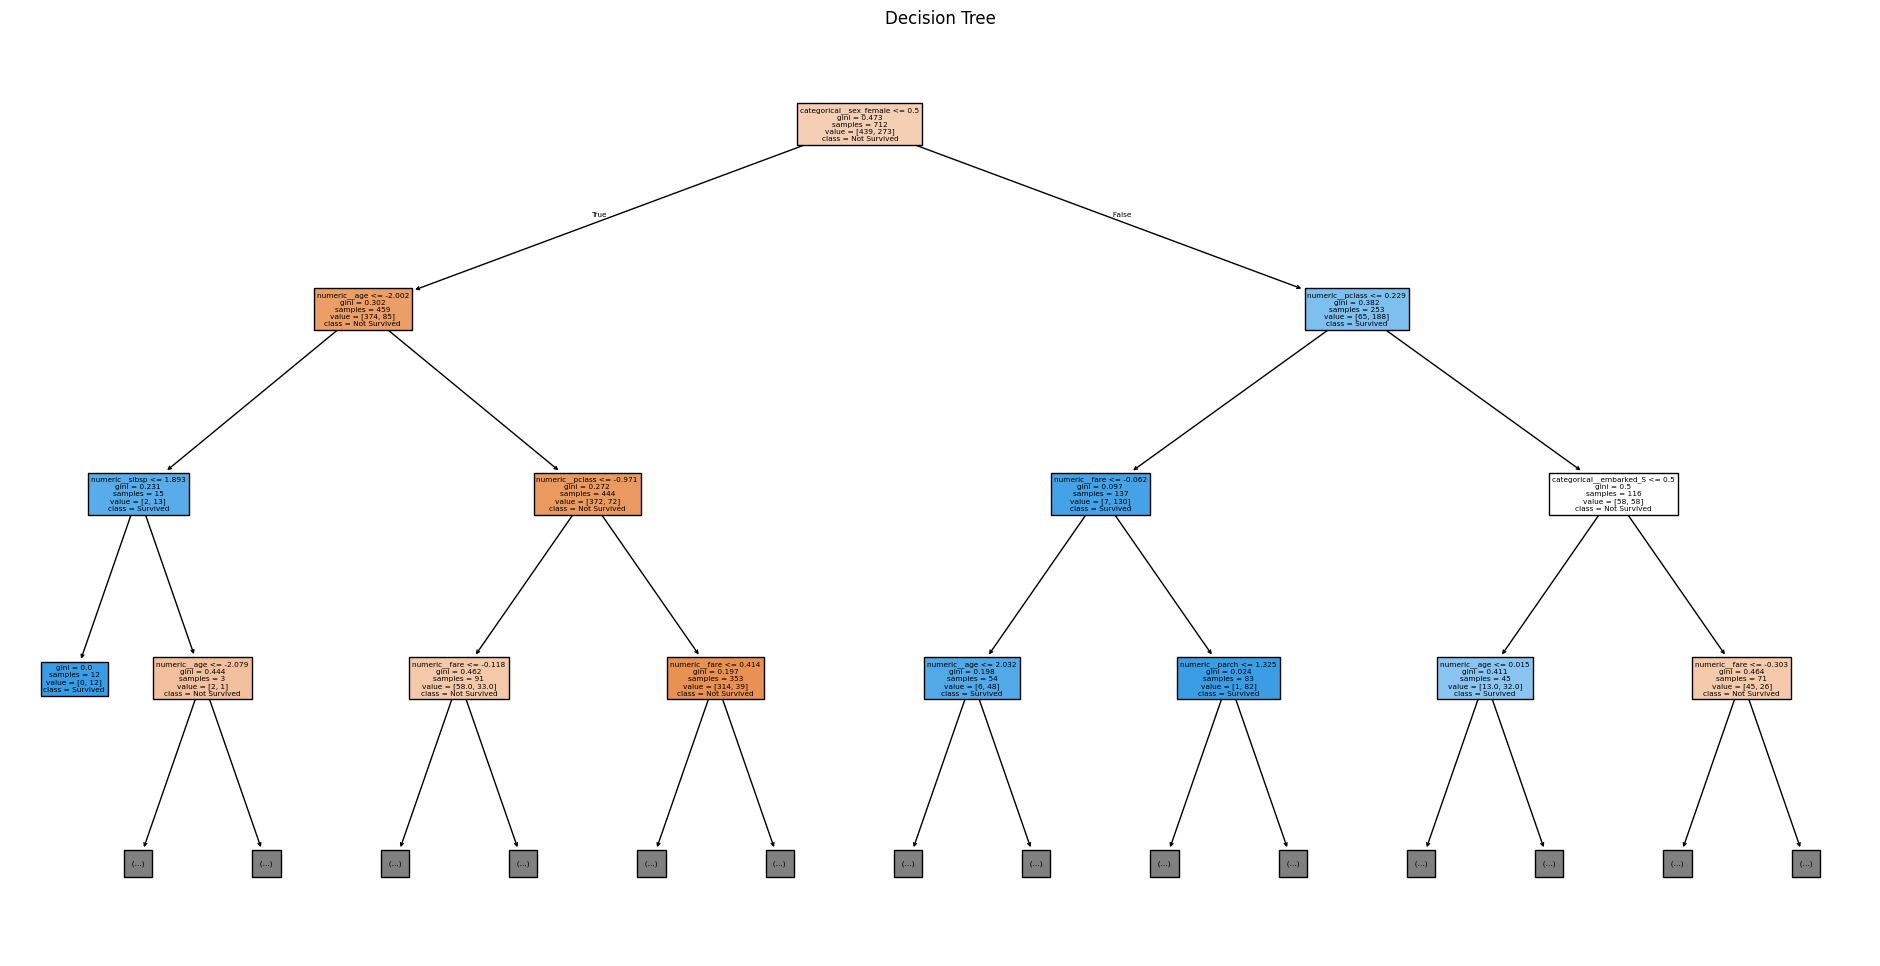

survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


,Strategy,Precision,Recall,F1
0,Baseline,0.793103,0.666667,0.724409
1,Class Weight Balanced,0.729730,0.782609,0.755245
2,SMOTE,0.739726,0.782609,0.760563


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'embarked'])])),
                                       ('classifier',
                                        RandomForestClassifier(oob_score=True,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10, 15],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='f1')

In [13]:
#Evaluate all models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "precision": precision_score(
            y_test,
            predictions
        ),
        "recall": recall_score(
            y_test,
            predictions
        ),
        "f1": f1_score(
            y_test,
            predictions
        ),
        "auc": roc_auc_score(
            y_test,
            probabilities
        )
    }

    return metrics, predictions, probabilities


#Generate model comparison

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline
}

results = []

for name, model in models.items():

    metrics, predictions, probabilities = (
        evaluate_model(
            model,
            X_test,
            y_test
        )
    )

    results.append({
        "Model": name,
        **metrics
    })

classification_results = pd.DataFrame(results)

display(classification_results)

#Confusion matrices

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, (name, model) in zip(
    axes,
    models.items()
):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()


#ROC curves

plt.figure(figsize=(8, 6))

for name, model in models.items():

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()
plt.tight_layout()
plt.show()


#Decision Tree visualization

tree_model = tree_pipeline.named_steps[
    "classifier"
]

fitted_preprocessor = (
    tree_pipeline
    .named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree")
plt.show()


#Class imbalance comparison

print(
    y_train.value_counts(
        normalize=True
    )
)

#Then compare: baseline, class_weight="balanced", SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

#Baseline:

baseline_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

#Balanced:

balanced_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

#SMOTE:

smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

#Fit each:

imbalance_models = {
    "Baseline": baseline_pipeline,
    "Class Weight Balanced": balanced_pipeline,
    "SMOTE": smote_pipeline
}

imbalance_results = []

for name, model in imbalance_models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    imbalance_results.append({
        "Strategy": name,
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1": f1_score(
            y_test,
            predictions
        )
    })

imbalance_results = pd.DataFrame(
    imbalance_results
)

display(imbalance_results)


#Random Forest GridSearchCV

from sklearn.model_selection import GridSearchCV

#Create an OOB-enabled forest:

rf_oob = RandomForestClassifier(


    random_state=42,
    oob_score=True
)

#Pipeline:

rf_grid_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf_oob)
])


#Parameter grid:

param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300
    ],
    "classifier__max_depth": [
        None,
        5,
        10,
        15
    ],
    "classifier__max_features": [
        "sqrt",
        "log2"
    ]
}


grid_search = GridSearchCV(
    rf_grid_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

In [14]:
#Report:

print(
    "Best parameters:",
    grid_search.best_params_
)

best_rf_pipeline = grid_search.best_estimator_

best_rf = (
    best_rf_pipeline
    .named_steps["classifier"]
)

print(
    "OOB score:",
    best_rf.oob_score_
)

#Regression side-task

#Target: fare

regression_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "sex",
    "embarked"
]

#Prepare:

X_reg = df[regression_features]
y_reg = df["fare"]


#Split:


X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

Best parameters: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
OOB score: 0.827247191011236


In [16]:
#Use a preprocessing pipeline followed by:

from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define numeric and categorical features for the regression task
numeric_features_reg = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

categorical_features_reg = [
    "sex",
    "embarked"
]

# Numeric pipeline for regression features
numeric_pipeline_reg = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Categorical pipeline for regression features
categorical_pipeline_reg = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

# Preprocessor for regression task
preprocessor_reg = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline_reg,
        numeric_features_reg
    ),
    (
        "categorical",
        categorical_pipeline_reg,
        categorical_features_reg
    )
])

regression_pipeline = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('regressor', LinearRegression())])

In [17]:
#Regression metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

reg_predictions = regression_pipeline.predict(
    X_reg_test
)

mae = mean_absolute_error(
    y_reg_test,
    reg_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        reg_predictions
    )
)

r2 = r2_score(
    y_reg_test,
    reg_predictions
)

n = len(y_reg_test)

p = X_reg_test.shape[1]

adjusted_r2 = (
    1 -
    (1 - r2) *
    (n - 1) /
    (n - p - 1)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

MAE: 20.809397730838686
RMSE: 30.47314546284871
R²: 0.399899948444019
Adjusted R²: 0.378966225715322


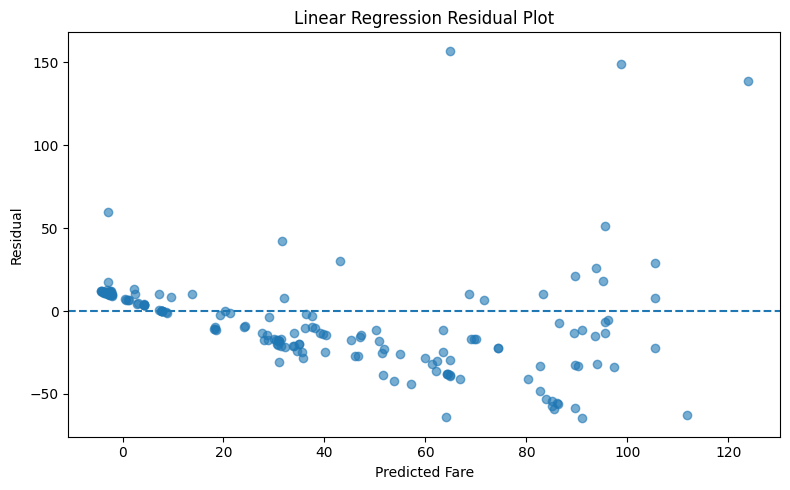

In [20]:
#Residual plot

import os

residuals = (
    y_reg_test -
    reg_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    reg_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Linear Regression Residual Plot")

plt.tight_layout()

# Create the 'charts' directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

plt.savefig(
    "charts/residual_plot.png"
)

plt.show()

In [21]:
#Final comparison table


classification_table = classification_results[
    [
        "Model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc"
    ]
].copy()

classification_table


classification_table = classification_results[
    [
        "Model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc"
    ]
].copy()

classification_table

,Model,accuracy,precision,recall,f1,auc
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
1,Decision Tree,0.765363,0.754717,0.579710,0.655738,0.797101
2,Random Forest,0.815642,0.800000,0.695652,0.744186,0.830040


In [22]:
#Final model recommendation -


#Save the COMPLETE pipeline

import joblib

full_pipeline = best_rf_pipeline

joblib.dump(
    full_pipeline,
    "best_titanic_pipeline.joblib"
)

print("Complete pipeline saved.")


Complete pipeline saved.


In [23]:
#Reload and test the pipeline

loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

sample_raw = X_test.iloc[:5]

predictions = loaded_pipeline.predict(
    sample_raw
)

print("Raw input:")
display(sample_raw)

print("Predictions:")
print(predictions)

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked
565,3,male,24.0,2,0,24.1500,S
160,3,male,44.0,0,1,16.1000,S
553,3,male,22.0,0,0,7.2250,C
860,3,male,41.0,2,0,14.1083,S
241,3,female,NaN,1,0,15.5000,Q


Predictions:
[0 0 0 0 1]
